<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/GaussianMixtureModel/GMMSilhouetteScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GMM and Silhouette Score

In [22]:
#Create a synthetic data with 500 samples, 2 features and 4 clusters
from sklearn.datasets import make_blobs
x, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.7, random_state=42)

In [23]:
x.shape

(500, 2)

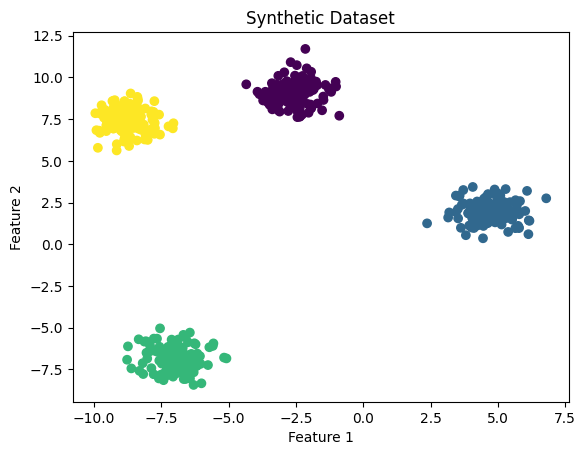

In [24]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0], x[:,1], c=y_true, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Dataset')
plt.show()

In [29]:
#Try clustering this data using guassian mixture
# and differen number of cluster 2-8. Calculate
# the silhouette score for each clustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
sil_score = []
for k in range(2,8):
  gauss_model=GaussianMixture(n_components=k, random_state=42)
  labels = gauss_model.fit_predict(x)
  score = silhouette_score(x, labels)
  sil_score.append(score)
  print(f"K={k}, Silouette Score={score:.3f}")

K=2, Silouette Score=0.613
K=3, Silouette Score=0.792
K=4, Silouette Score=0.855
K=5, Silouette Score=0.735
K=6, Silouette Score=0.596
K=7, Silouette Score=0.484


- Silhouette score ranges from -1 to 1. -1 being the worst and 1 being the best. We can see the Silouette score for k=4 is the higest among all. We knoe from our data that origionally 4 clusters are present.

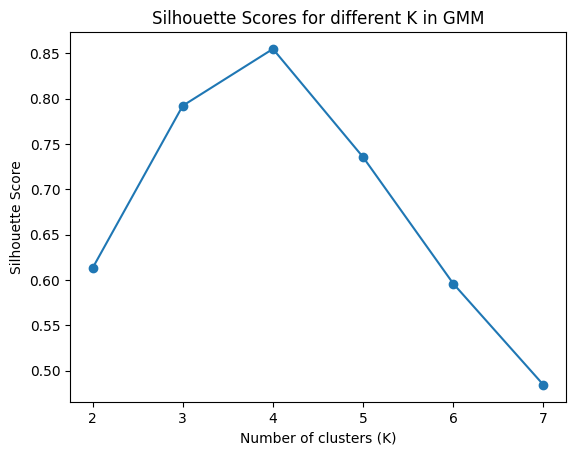

In [30]:
#Plot Silhouette score vs K graph
plt.plot(range(2,8), sil_score, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for different K in GMM")
plt.show()

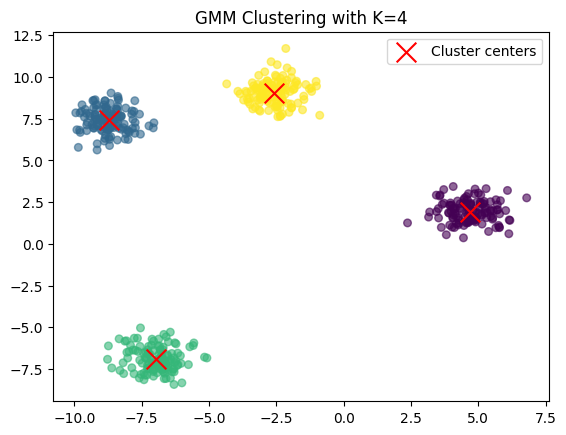

In [32]:
#Create GMM with k=4
GMM_Model=GaussianMixture(n_components=4, random_state=42)
labels = GMM_Model.fit_predict(x)
plt.scatter(x[:, 0], x[:, 1], c=labels, cmap="viridis", s=30, alpha=0.6)
plt.scatter(GMM_Model.means_[:, 0], GMM_Model.means_[:, 1], marker='x', s=200, c="red", label="Cluster centers")
plt.title(f"GMM Clustering with K={4}")
plt.legend()
plt.show()